In [1]:
import pandas as pd
from tqdm import tqdm
from time import time
import numpy as np
import matplotlib.pyplot as plt

In [72]:
#Birth an death
def evolve(k,gamma,tmax,n):
    if n==0:
        tr=-(1/k)*np.log(np.random.rand())
        reaction=0
    else:
        t1=-(1/k)*np.log(np.random.rand())
        t2=-(1/(gamma*n))*np.log(np.random.rand())
        tr=np.min([t1,t2])
        reaction=np.argmin([t1,t2])
    t=0
    if tr>tmax:
        return s
    else:
        while t+tr<tmax:
            t=t+tr
            if reaction==0:
                n=n+1
            else:
                n+=-1
            if n==0:
                tr=-(1/k)*np.log(np.random.rand())
                reaction=0
            else:

                t1=-(1/k)*np.log(np.random.rand())
                t2=-(1/(gamma*n))*np.log(np.random.rand())
                tr=np.min([t1,t2])
                reaction=np.argmin([t1,t2])
            
           #print(s)
        return n

In [73]:
t=0
dt=0.001
s=0
data=[[t,s]]
lamb=1
tmax=10
while t<tmax:
    s=evolve(k=10,gamma=1,tmax=dt,n=s)
    t+=dt
    data.append([t,s])

Text(0, 0.5, 'Protein')

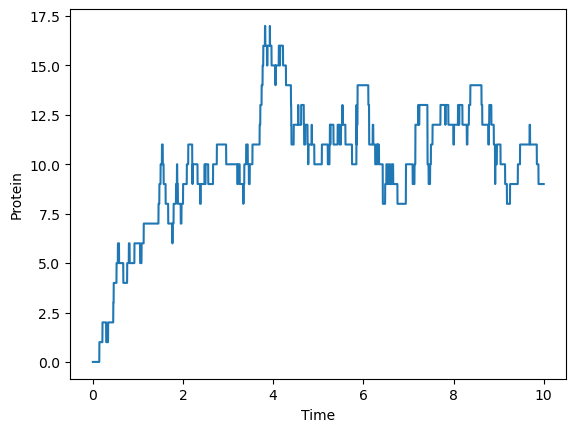

In [74]:
df=pd.DataFrame(data,columns=['Time','State'])
plt.plot(df.Time,df.State)
plt.xlabel('Time')
plt.ylabel('Protein')

In [76]:
#non markovian Poisson
cv2t=1/10
def gett():
    return np.random.gamma(shape=1/cv2t,scale=cv2t)
def evolve(tmax,tr,s):
    if tr>tmax:
        tr=tr-tmax
        
    else:
        tt=tmax
        while tt>tr:
            tt=tt-tr
            s=s+1
            tr=gett()
        tr=tr-tt
    return s,tr


In [104]:
t=0
dt=0.001
s=0
data=[[t,s]]
lamb=1
tmax=4
tr=gett()
while t<tmax:
    
    s,tr=evolve(tmax=dt,tr=tr,s=s)
    
    t+=dt
    data.append([t,s])
    #print(s,t)

Text(0.5, 0, 'time')

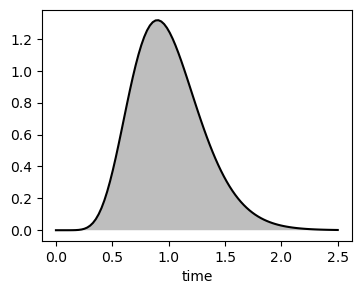

In [103]:
from scipy.stats import erlang
fig=plt.figure(figsize=(4,3))
xarr=np.linspace(0,2.5,100)
pdf=erlang.pdf(xarr, a=10,scale=1/10)
plt.plot(xarr,pdf,c='k')
plt.fill_between(xarr,[0]*len(pdf),pdf,facecolor='#bebebe')
plt.xlabel('time')

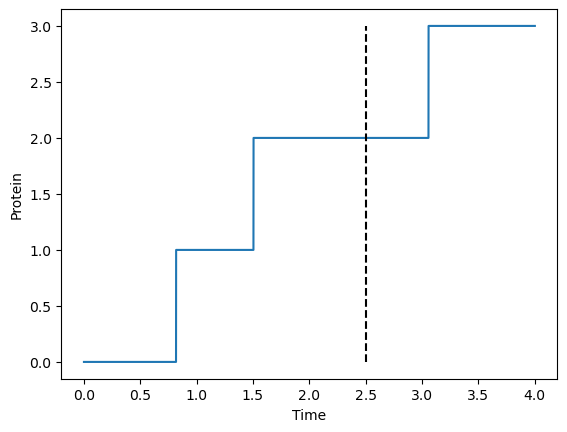

In [106]:
df=pd.DataFrame(data,columns=['Time','State'])
plt.plot(df.Time,df.State)
plt.xlabel('Time')
plt.ylabel('Protein')
plt.plot([2.5,2.5],[0,3],'k--')

Text(0, 0.5, 'Protein')

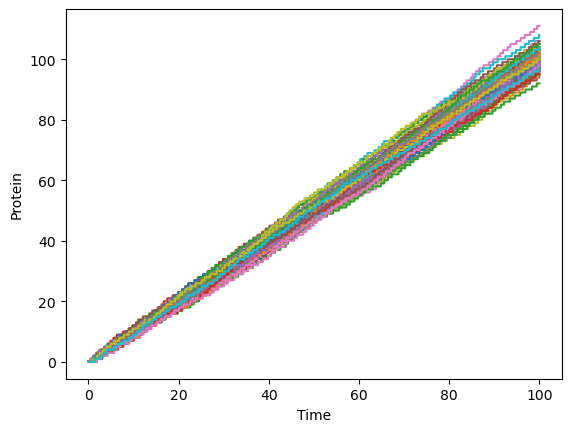

In [107]:


lamb=1
tmax=100

for i in range(100):
    #print(i)
    
    t=0
    dt=0.01
    s=0
    data=[[t,s]]
    tr=gett()
    while t<tmax:

        s,tr=evolve(tmax=dt,tr=tr,s=s)

        t+=dt
        data.append([t,s])
    df=pd.DataFrame(data,columns=['Time','State'])
    plt.plot(df.Time,df.State)
plt.xlabel('Time')
plt.ylabel('Protein')